## Comparing the Mean Field and the corresponding Neural Network simulation results 

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

In this notebook we load the MF and NN simulation results (obtained using *MF_heatmap_data.py* and *NN_heatmap_data.py*) and compare them.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import h5py

In [2]:
import sys 
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..', '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [3]:
from utils.Sim_helper import *
from utils.Plots_helper import *
import seaborn as sns
import numpy as np

INFO       Cache size for target "cython": 1312 MB.
You can call "clear_cache('cython')" to delete all files from the cache or manually delete files in the "/home/ilaria/.cython/brian_extensions" directory. [brian2]


In [4]:
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '-figs.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig) 

In [5]:
fig_name = 'MF_NN_comparison'

## FS

In [6]:
# Loading FS the data
df_mf = load_sim_data('simulations/val_MF_[0_30]', model_type="MF")
df_nn = load_sim_data('simulations/val_NN_[0_30]', model_type="NN")

In [7]:
fs_mf_data = get_pivot(df_mf, 'fs_avg')
fs_nn_data = get_pivot(df_nn, 'fs_avg')
fs_nn_std_data = get_pivot(df_nn, 'fs_std')

In [8]:
#fs_mf_data, fs_nn_data

### FS comparison plots

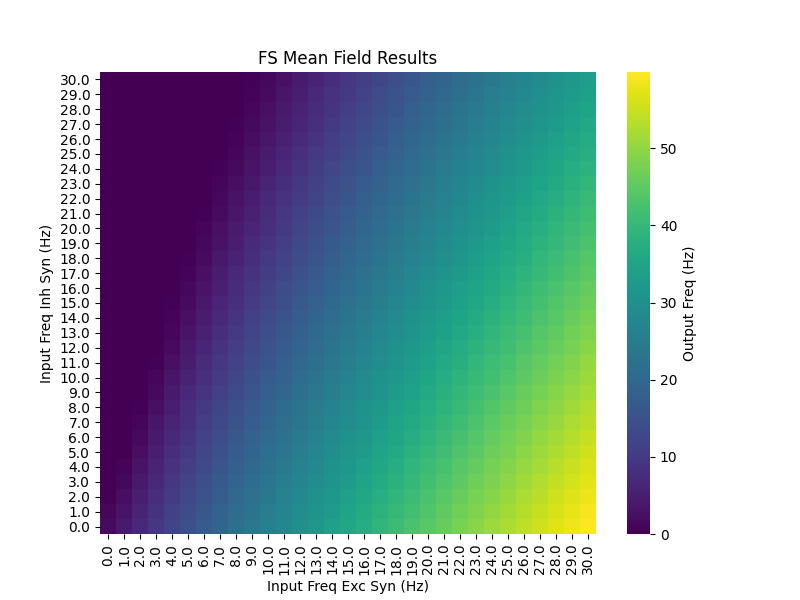

In [9]:
fig = plot_heatmap_simulation('FS', 'Mean Field', fs_mf_data)

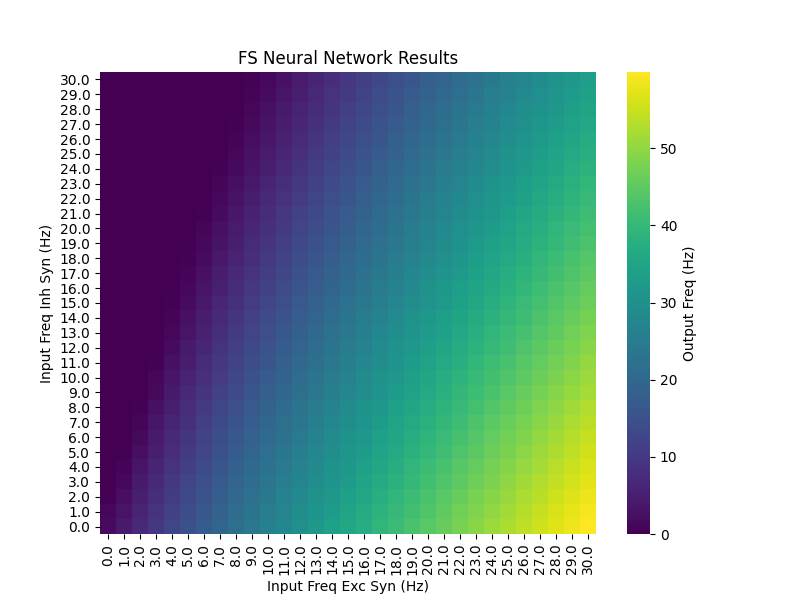

In [10]:
fig = plot_heatmap_simulation('FS', 'Neural Network', fs_mf_data)

In [11]:
# Computing the difference between MF and NN
fs_diff_data = fs_mf_data - fs_nn_data

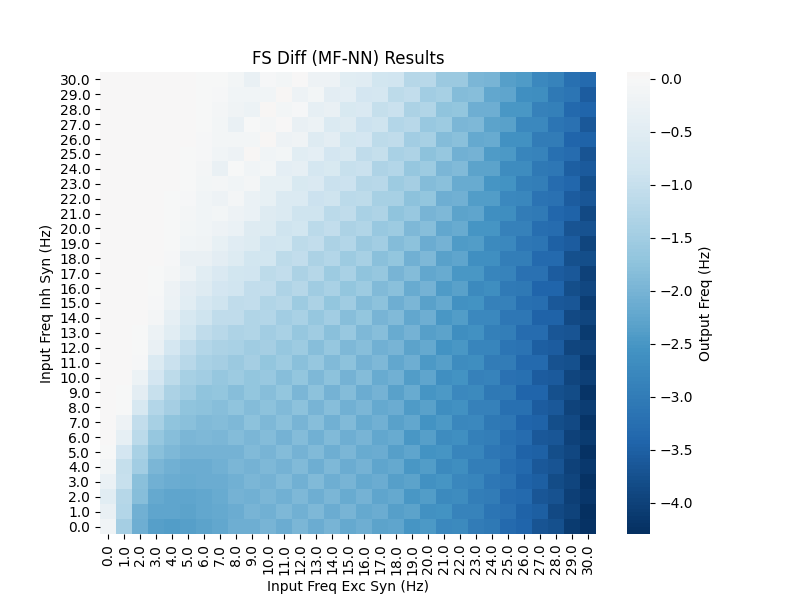

In [12]:
fig = plot_heatmap_diff_simulation('FS', fs_diff_data)

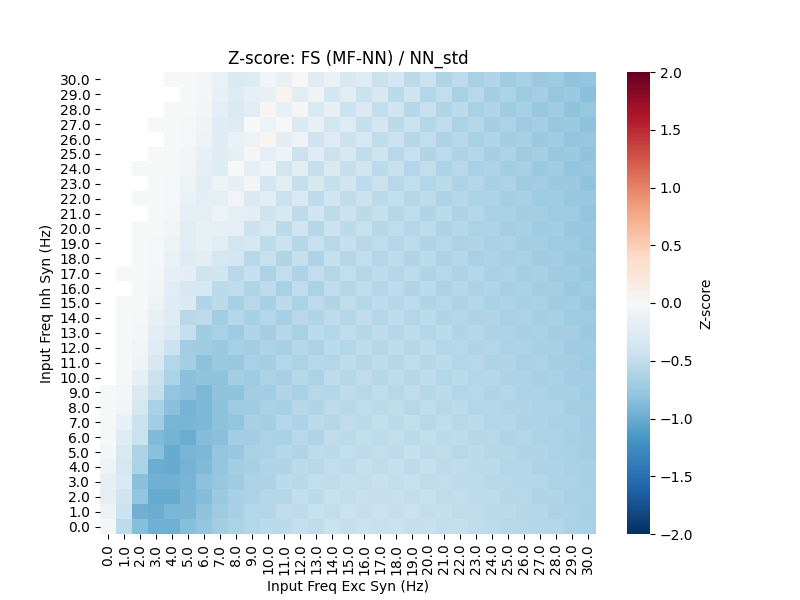

In [13]:
# Calculating Z-score
fs_z_score = (fs_mf_data - fs_nn_data) / fs_nn_std_data

plot_heatmap_z_score('FS', fs_z_score, annotate = False)

figs.append(fig)

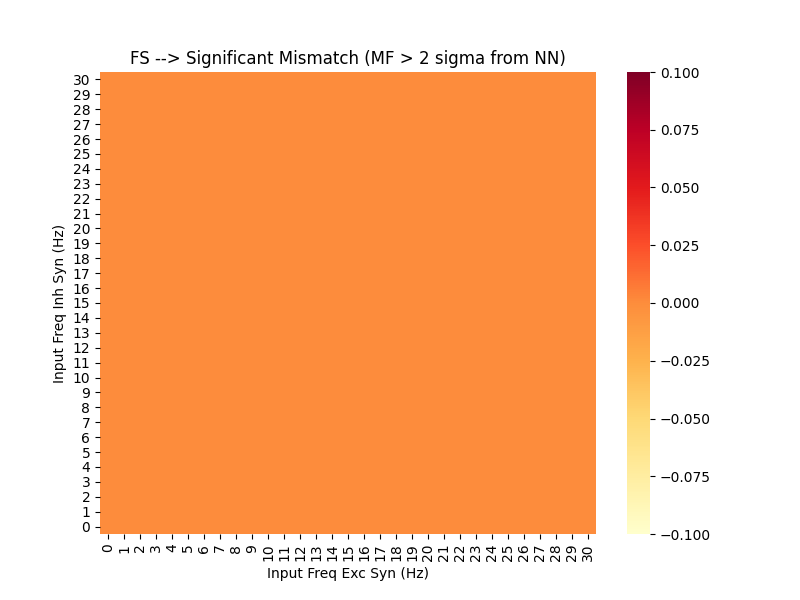

In [14]:
# Boolean mask: Is the MF more than 2 std away?
eps = 1e-3 # Trick to avoid division by zero when fs_nn_std_data = 0
diff = np.abs(fs_mf_data - fs_nn_data)
mismatch_mask = np.where(
    fs_nn_std_data == 0,
    diff > eps,
    diff > 2 * fs_nn_std_data
)

fig = plot_mismatch_heatmap('FS', mismatch_mask, annotate = False)
figs.append(fig)

## RS

In [15]:
# Loading the results
rs_mf_data = get_pivot(df_mf, 'rs_avg')
rs_nn_data = get_pivot(df_nn, 'rs_avg')
rs_nn_std_data = get_pivot(df_nn, 'rs_std')

### RS comparison plots

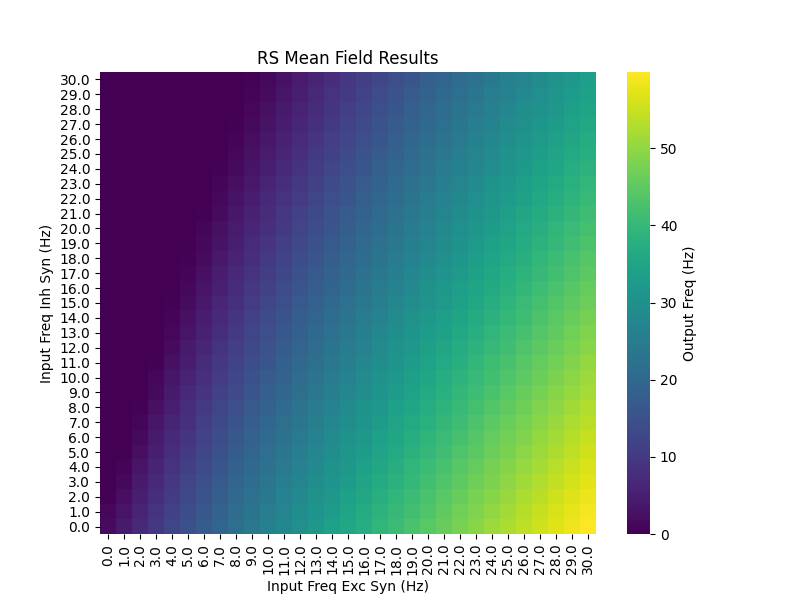

In [16]:
fig = plot_heatmap_simulation('RS', 'Mean Field', fs_mf_data)

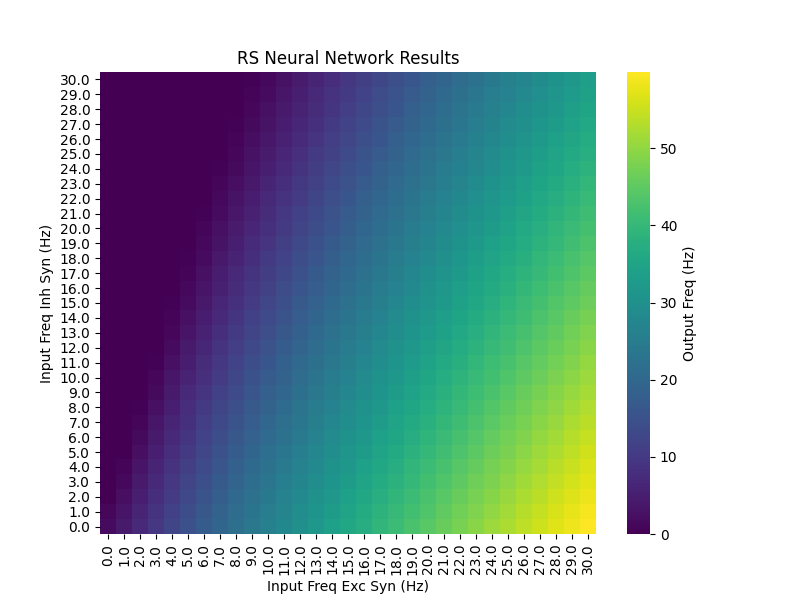

In [17]:
fig = plot_heatmap_simulation('RS', 'Neural Network', fs_mf_data)

In [18]:
rs_diff_data = rs_mf_data - rs_nn_data

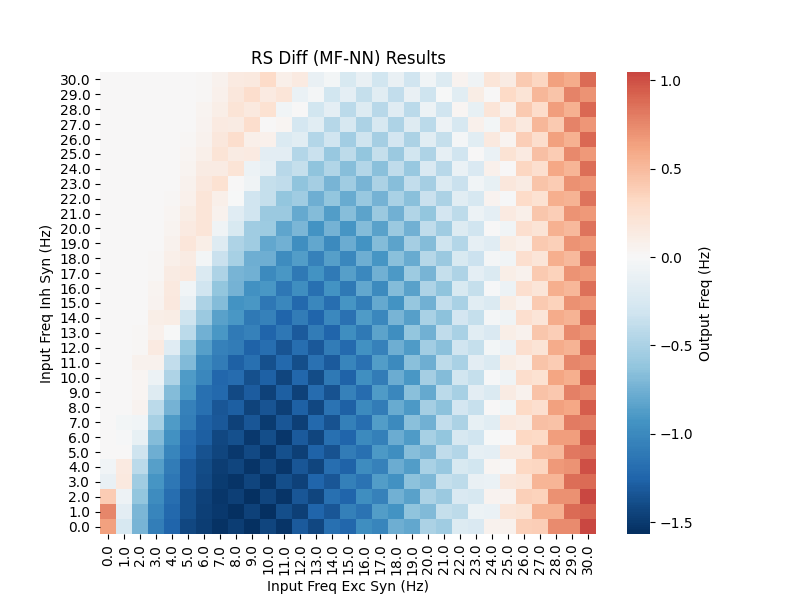

In [19]:
fig = plot_heatmap_diff_simulation('RS', rs_diff_data)

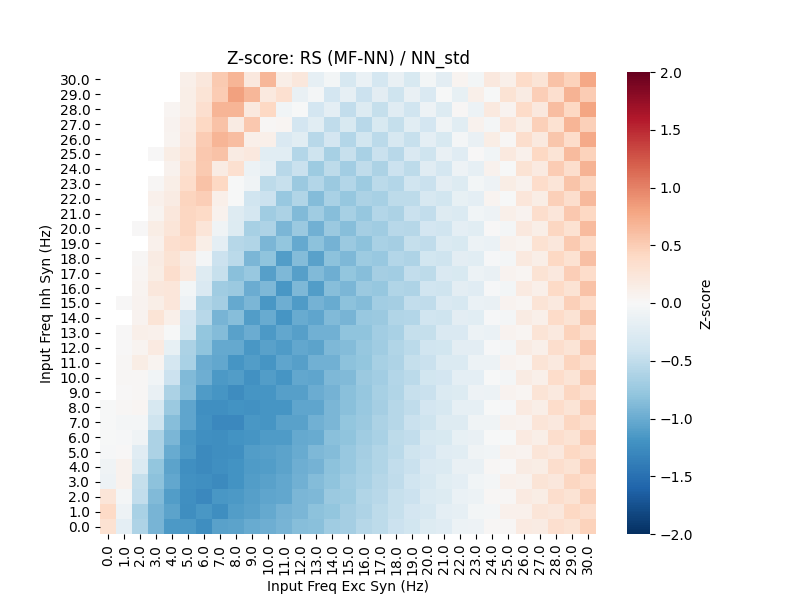

In [20]:
# Calculating Z-score
rs_z_score = (rs_mf_data - rs_nn_data) / rs_nn_std_data

plot_heatmap_z_score('RS', rs_z_score, annotate = False)

figs.append(fig)

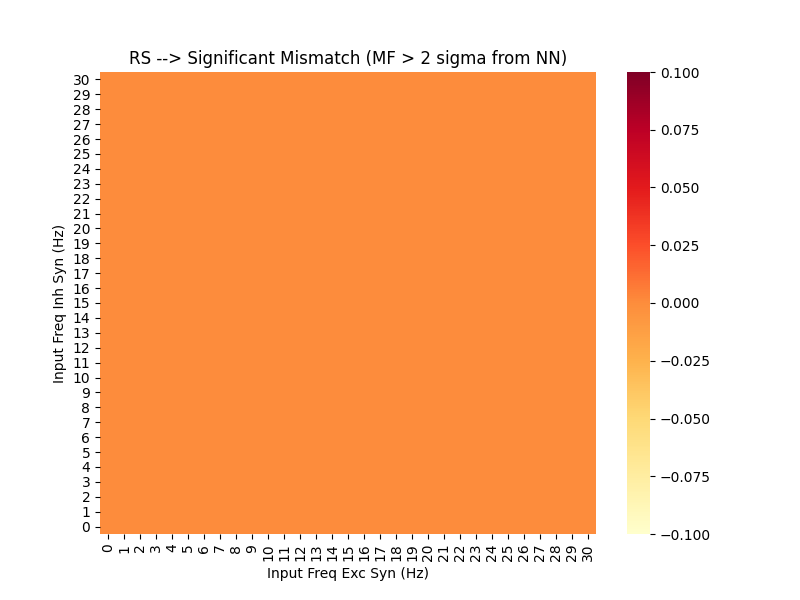

In [21]:
# Boolean mask: Is the MF more than 2 std away?
eps = 1e-3 # Trick to avoid division by zero when fs_nn_std_data = 0
diff = np.abs(rs_mf_data - rs_nn_data)
mismatch_mask = np.where(
    rs_nn_std_data == 0,
    diff > eps,
    diff > 2 * rs_nn_std_data
)

fig = plot_mismatch_heatmap('RS', mismatch_mask, annotate = False)
figs.append(fig)

In [22]:
save_figs(fig_path, fig_name, figs)